In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# SELECTION_METRIC must match rfe.ipynb; it maps to the sklearn scoring name used for
# hyperparameter tuning so tuning optimizes the same objective as feature selection.
# BEST_NUM_FEATS (from rfe.ipynb's 1-SE output) and SELECTED_RFE_CSV are set per run.
SELECTION_METRIC = 'brier'
_SCORING = {'brier': 'neg_brier_score', 'roc_auc': 'roc_auc', 'log_loss': 'neg_log_loss'}[SELECTION_METRIC]
BEST_NUM_FEATS = 24
SELECTED_RFE_CSV = 'rfe_features_kfolds_brier.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring=_SCORING,
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63856	validation_1-auc:0.62840
[1]	validation_0-auc:0.66670	validation_1-auc:0.63887
[2]	validation_0-auc:0.67314	validation_1-auc:0.64056
[3]	validation_0-auc:0.67976	validation_1-auc:0.64661
[4]	validation_0-auc:0.68429	validation_1-auc:0.64908
[5]	validation_0-auc:0.68673	validation_1-auc:0.64964
[6]	validation_0-auc:0.68862	validation_1-auc:0.65225
[7]	validation_0-auc:0.69263	validation_1-auc:0.65161
[0]	validation_0-auc:0.63964	validation_1-auc:0.62303
[8]	validation_0-auc:0.69430	validation_1-auc:0.64734
[1]	validation_0-auc:0.66734	validation_1-auc:0.64604
[9]	validation_0-auc:0.69531	validation_1-auc:0.64591
[2]	validation_0-auc:0.67747	validation_1-auc:0.64956
[10]	validation_0-auc:0.69753	validation_1-auc:0.64671
[3]	validation_0-auc:0.68350	validation_1-auc:0.65319
[11]	validation_0-auc:0.69977	validation_1-auc:0.64790
[4]	validation_0-auc:0.69206	validation_1-auc:0.65325
[12]	validation_0-auc:0.70151	validation_1-auc:0.64969
[0]	validation_0-auc:0.63

[35]	validation_0-auc:0.69326	validation_1-auc:0.65553
[13]	validation_0-auc:0.69850	validation_1-auc:0.65966
[39]	validation_0-auc:0.69648	validation_1-auc:0.66009
[18]	validation_0-auc:0.71723	validation_1-auc:0.65609
[14]	validation_0-auc:0.69990	validation_1-auc:0.66256
[1]	validation_0-auc:0.65440	validation_1-auc:0.63123
[36]	validation_0-auc:0.69395	validation_1-auc:0.65522
[49]	validation_0-auc:0.69780	validation_1-auc:0.66201
[12]	validation_0-auc:0.70796	validation_1-auc:0.65523
[40]	validation_0-auc:0.69669	validation_1-auc:0.66002
[19]	validation_0-auc:0.71835	validation_1-auc:0.65772
[15]	validation_0-auc:0.70043	validation_1-auc:0.66110
[2]	validation_0-auc:0.67585	validation_1-auc:0.64700
[0]	validation_0-auc:0.63420	validation_1-auc:0.61165
[37]	validation_0-auc:0.69451	validation_1-auc:0.65430
[41]	validation_0-auc:0.69686	validation_1-auc:0.66019
[20]	validation_0-auc:0.71882	validation_1-auc:0.65691
[16]	validation_0-auc:0.70245	validation_1-auc:0.66169
[3]	validatio

[12]	validation_0-auc:0.65899	validation_1-auc:0.64225
[18]	validation_0-auc:0.65037	validation_1-auc:0.63132
[18]	validation_0-auc:0.65550	validation_1-auc:0.63361
[7]	validation_0-auc:0.62396	validation_1-auc:0.60522
[10]	validation_0-auc:0.57394	validation_1-auc:0.56423
[1]	validation_0-auc:0.60806	validation_1-auc:0.58361
[13]	validation_0-auc:0.65899	validation_1-auc:0.64225
[19]	validation_0-auc:0.65037	validation_1-auc:0.63132
[19]	validation_0-auc:0.65550	validation_1-auc:0.63361
[8]	validation_0-auc:0.62200	validation_1-auc:0.60305
[2]	validation_0-auc:0.63511	validation_1-auc:0.61317
[14]	validation_0-auc:0.65899	validation_1-auc:0.64225
[9]	validation_0-auc:0.62200	validation_1-auc:0.60305
[11]	validation_0-auc:0.61260	validation_1-auc:0.59208
[15]	validation_0-auc:0.65899	validation_1-auc:0.64225
[3]	validation_0-auc:0.63060	validation_1-auc:0.60757
[10]	validation_0-auc:0.62200	validation_1-auc:0.60305
[12]	validation_0-auc:0.61260	validation_1-auc:0.59208
[16]	validation_

[22]	validation_0-auc:0.67905	validation_1-auc:0.65012
[27]	validation_0-auc:0.69929	validation_1-auc:0.66334
[21]	validation_0-auc:0.67820	validation_1-auc:0.65328
[15]	validation_0-auc:0.67224	validation_1-auc:0.64430
[26]	validation_0-auc:0.68175	validation_1-auc:0.65517
[32]	validation_0-auc:0.66723	validation_1-auc:0.64767
[20]	validation_0-auc:0.69322	validation_1-auc:0.65645
[16]	validation_0-auc:0.69013	validation_1-auc:0.65934
[13]	validation_0-auc:0.68454	validation_1-auc:0.65321
[23]	validation_0-auc:0.69819	validation_1-auc:0.66432
[23]	validation_0-auc:0.67984	validation_1-auc:0.65244
[22]	validation_0-auc:0.68004	validation_1-auc:0.65490
[28]	validation_0-auc:0.70003	validation_1-auc:0.66269
[16]	validation_0-auc:0.67158	validation_1-auc:0.64488
[27]	validation_0-auc:0.68218	validation_1-auc:0.65548
[33]	validation_0-auc:0.66723	validation_1-auc:0.64767
[21]	validation_0-auc:0.69434	validation_1-auc:0.65701
[17]	validation_0-auc:0.69079	validation_1-auc:0.65946
[14]	valid

[8]	validation_0-auc:0.65885	validation_1-auc:0.64123
[12]	validation_0-auc:0.69207	validation_1-auc:0.66035
[4]	validation_0-auc:0.66458	validation_1-auc:0.64201
[6]	validation_0-auc:0.67004	validation_1-auc:0.64876
[1]	validation_0-auc:0.65886	validation_1-auc:0.63587
[0]	validation_0-auc:0.60921	validation_1-auc:0.60216
[0]	validation_0-auc:0.61376	validation_1-auc:0.59689
[9]	validation_0-auc:0.66572	validation_1-auc:0.64597
[13]	validation_0-auc:0.69261	validation_1-auc:0.66196
[5]	validation_0-auc:0.67156	validation_1-auc:0.64569
[1]	validation_0-auc:0.63869	validation_1-auc:0.62756
[1]	validation_0-auc:0.63638	validation_1-auc:0.62174
[6]	validation_0-auc:0.67324	validation_1-auc:0.65052
[14]	validation_0-auc:0.69267	validation_1-auc:0.66241
[8]	validation_0-auc:0.68545	validation_1-auc:0.66071
[2]	validation_0-auc:0.66731	validation_1-auc:0.64330
[8]	validation_0-auc:0.67283	validation_1-auc:0.64890
[2]	validation_0-auc:0.65804	validation_1-auc:0.63160
[2]	validation_0-auc:0.66

...

[46]	validation_0-auc:0.71014	validation_1-auc:0.66182


[47]	validation_0-auc:0.71045	validation_1-auc:0.66159


[48]	validation_0-auc:0.71092	validation_1-auc:0.66122


[49]	validation_0-auc:0.71128	validation_1-auc:0.66125




Best parameters found:  {'subsample': 0.5, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 2, 'learning_rate': 0.15, 'importance_type': 'total_gain', 'gamma': 0.5, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  -0.22340758214307202


Best Selected Features:  ['off_target_success_rate_competitive_cumulative_average_rank', 'target_off_cumulative_avg_score_rank', 'off_target_sack_yards_cumulative_average_rank', 'off_opp_early_down_success_rate_competitive_cumulative_average_rank', 'def_opp_pass_short_left_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'off_opp_down3_short_conversion_rate_run_competitive_cumulative_average_rank', 'off_target_third_down_conversion_rate_garbage_trailing_cumulative_average_rank', 'def_target_pass_deep_middle_explosive_rate_competitive_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'def_target_rushing_yards_cumulative_average_rank', 'off_target_down3_short_pass_rate_competitive_cumul

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.13432813, 0.1474802 , 0.12576647, 0.13046098, 0.144555  ,
        0.05169373, 0.07349825, 0.06906543, 0.11071959, 0.11591496,
        0.0465548 , 0.04432635, 0.12273207, 0.10704474, 0.13613758,
        0.07765698, 0.07437415, 0.09763207, 0.06811562, 0.05681   ,
        0.05448647, 0.07589297, 0.12168117, 0.10754066, 0.10883613,
        0.14975882, 0.06796947, 0.07391582, 0.10849018, 0.10381451,
        0.09090924, 0.15816832, 0.07011938, 0.12375059, 0.04611249,
        0.05064645, 0.08150177, 0.10185218, 0.04489155, 0.07023864,
        0.13029575, 0.14303069, 0.06474638, 0.06746936, 0.11293302,
        0.05450191, 0.04377041, 0.07624226, 0.08983297, 0.14639368,
        0.09896073, 0.04514709, 0.16079955, 0.0647542 , 0.11555037,
        0.07586198, 0.15831485, 0.05302076, 0.12143412, 0.06454391,
        0.10139399, 0.09268508, 0.05248523, 0.04756927, 0.07863755,
        0.09467263, 0.06518884, 0.08189106, 0.09721394, 0.15230484,
        0.09687591, 0.07482381,

<Axes: >

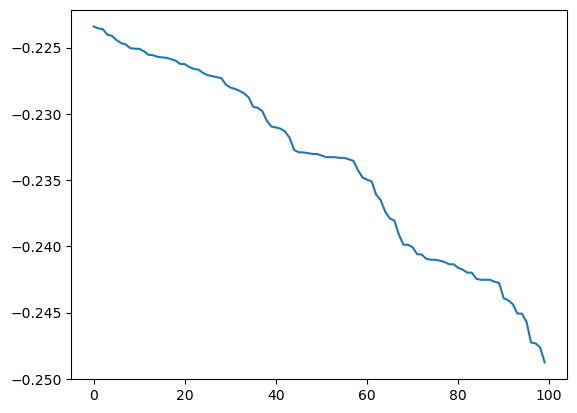

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.160800,0.017670,0.002385,0.001307,0.5,50,50,2,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.224605,-0.225163,-0.224449,-0.222118,-0.220703,-0.223408,0.001707,1
1,0.158315,0.014415,0.002753,0.001605,0.5,50,50,3,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.223509,-0.223845,-0.225272,-0.222421,-0.222715,-0.223553,0.001002,2
2,0.125766,0.007564,0.001869,0.000150,0.9,40,50,3,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",-0.221580,-0.224510,-0.227221,-0.223970,-0.220790,-0.223614,0.002282,3
3,0.126948,0.013004,0.001698,0.000159,0.5,40,20,3,0.2,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 40, 'min_ch...",-0.223748,-0.225105,-0.226211,-0.223819,-0.221265,-0.224030,0.001654,4
4,0.128268,0.008670,0.002387,0.001238,0.7,40,100,3,0.2,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",-0.224472,-0.225113,-0.226341,-0.223614,-0.221049,-0.224118,0.001774,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6378676470588235

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Single overall hold-out AUROC, computed exactly like bart.ipynb, reported alongside
# Brier/log-loss so every run is comparable on all axes regardless of selection metric.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, {SELECTED_RFE_CSV}, selected on {SELECTION_METRIC}]')

2024+2025 hold-out ROC-AUC (overall): 0.6966  [24 features, rfe_features_kfolds_brier.csv, selected on brier]


In [13]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.221138
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.800300
2,2024_01_BAL_KC,1,KC,BAL,1,0.571044
3,2024_01_BAL_KC,1,BAL,KC,0,0.438664
4,2024_01_CAR_NO,1,CAR,NO,0,0.160219
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.608057
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.876895
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.183521
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.753134


week
1     0.841797
2     0.622070
3     0.525391
4     0.616211
5     0.484694
6     0.746730
7     0.790000
8     0.753864
9     0.728894
10    0.665816
11    0.794293
12    0.776406
13    0.728516
14    0.762689
15    0.786133
16    0.656250
17    0.665039
18    0.627930
dtype: float64

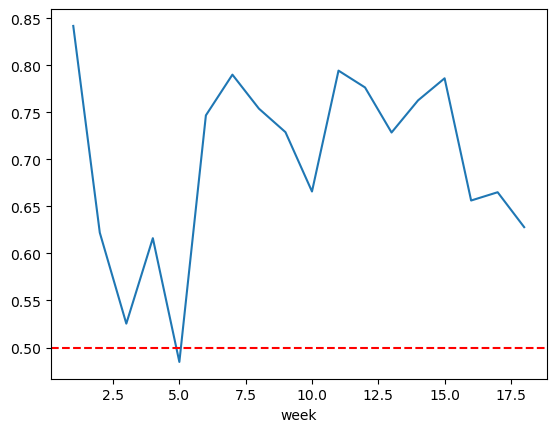

In [14]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [15]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.787440
2     0.566802
3     0.542969
4     0.761719
5     0.389744
6     0.722222
7     0.614907
8     0.705556
9     0.705556
10    0.544444
11    0.584416
12    0.564286
13    0.716667
14    0.685185
15    0.731818
16    0.583333
17    0.591667
18    0.634921
dtype: float64

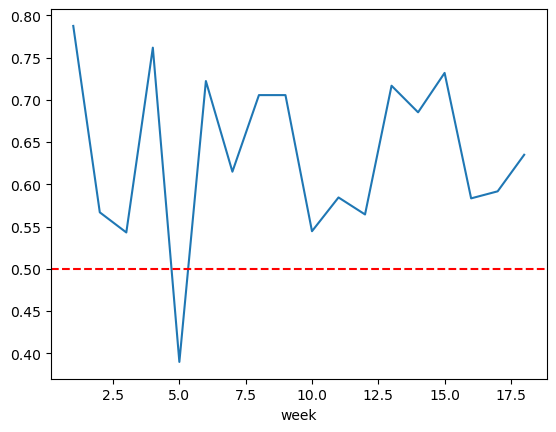

In [16]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [17]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2209  (lower is better; 0.25 = coin flip)
Log loss:    0.6318  (lower is better; punishes confident-and-wrong hardest)


In [18]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",206,0.577670,0.551248,-0.026422
"(0.6, 0.7]",154,0.655844,0.648197,-0.007647
"(0.7, 0.8]",116,0.741379,0.743345,0.001965
"(0.8, 0.9]",21,0.904762,0.833241,-0.071521


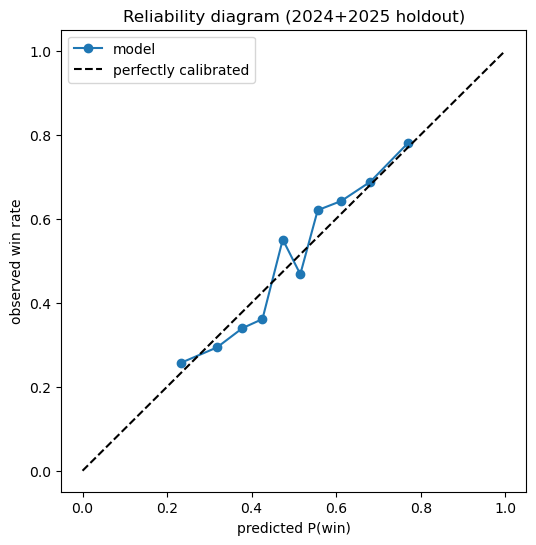

In [19]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [20]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.206


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.0009658000000000001, 0.0815]",109,0.038612,0.522936
"(0.0815, 0.175]",109,0.127108,0.550459
"(0.175, 0.295]",108,0.229303,0.657407
"(0.295, 0.424]",109,0.356068,0.706422
"(0.424, 0.784]",109,0.528965,0.779817


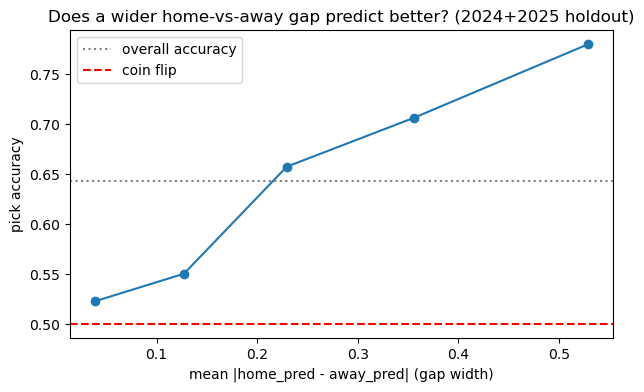

In [21]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()